# 06 — Monte Carlo NAV Simulation (Bonus B3)
Projects NAV growth over a 5-year horizon for selected funds using Geometric Brownian Motion, calibrated on each fund's historical daily return mean and volatility. Plots the median projected path with 5th–95th percentile uncertainty bands.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW_DIR = Path("../data/raw")
np.random.seed(42)

fund_master = pd.read_csv(RAW_DIR / "01_fund_master.csv")
nav_history = pd.read_csv(RAW_DIR / "02_nav_history.csv", parse_dates=["date"])
scheme_perf = pd.read_csv(RAW_DIR / "07_scheme_performance.csv")

nav_history = nav_history.sort_values(["amfi_code", "date"])
nav_history["daily_return"] = nav_history.groupby("amfi_code")["nav"].pct_change()

scheme_names = fund_master.set_index("amfi_code")["scheme_name"].to_dict()
print("Data loaded.")

Data loaded.


## Select funds to simulate
One representative fund per risk grade, so the simulation shows how projected uncertainty scales with risk category.

In [2]:
selected = []
for grade in ["Low", "Moderate", "High", "Very High"]:
    candidates = scheme_perf[scheme_perf["risk_grade"] == grade]
    if len(candidates):
        top = candidates.sort_values("aum_crore", ascending=False).iloc[0]
        selected.append(top["amfi_code"])

print("Selected funds for simulation:")
for code_ in selected:
    print(" -", scheme_names.get(code_, code_), f"({code_})")

Selected funds for simulation:
 - ICICI Pru Liquid Fund - Regular - Growth (120507)
 - DSP Top 100 Equity Fund - Regular - Growth (149322)
 - Kotak Emerging Equity Fund - Regular - Growth (120842)
 - Nippon India Small Cap Fund - Regular - Growth (118634)


## Monte Carlo GBM simulation
For each fund: estimate daily drift (mu) and volatility (sigma) from historical returns, then simulate 1,000 random 5-year (1,260 trading day) NAV paths using Geometric Brownian Motion:

`NAV(t+1) = NAV(t) * exp((mu - 0.5*sigma^2) + sigma * Z)`, where Z ~ N(0,1)

In [3]:
N_SIMULATIONS = 1000
N_DAYS = 252 * 5  # 5-year horizon, trading days

simulation_results = {}

for code_ in selected:
    sub = nav_history[nav_history["amfi_code"] == code_]
    returns = sub["daily_return"].dropna()
    mu = returns.mean()
    sigma = returns.std()
    last_nav = sub.sort_values("date")["nav"].iloc[-1]

    Z = np.random.standard_normal((N_SIMULATIONS, N_DAYS))
    daily_log_returns = (mu - 0.5 * sigma ** 2) + sigma * Z
    log_paths = np.cumsum(daily_log_returns, axis=1)
    nav_paths = last_nav * np.exp(log_paths)
    nav_paths = np.hstack([np.full((N_SIMULATIONS, 1), last_nav), nav_paths])

    simulation_results[code_] = {
        "paths": nav_paths,
        "mu": mu, "sigma": sigma, "last_nav": last_nav,
    }
    print(f"{scheme_names.get(code_, code_):<45} mu(daily)={mu:.5f}  sigma(daily)={sigma:.5f}  "
          f"start_nav={last_nav:.2f}")

ICICI Pru Liquid Fund - Regular - Growth      mu(daily)=0.00027  sigma(daily)=0.00031  start_nav=388.59
DSP Top 100 Equity Fund - Regular - Growth    mu(daily)=0.00052  sigma(daily)=0.00904  start_nav=606.23
Kotak Emerging Equity Fund - Regular - Growth mu(daily)=0.00031  sigma(daily)=0.01127  start_nav=82.65


Nippon India Small Cap Fund - Regular - Growth mu(daily)=0.00071  sigma(daily)=0.01590  start_nav=134.67


## Plot projected paths with uncertainty bands
Median path plus 5th–95th and 25th–75th percentile bands per fund.

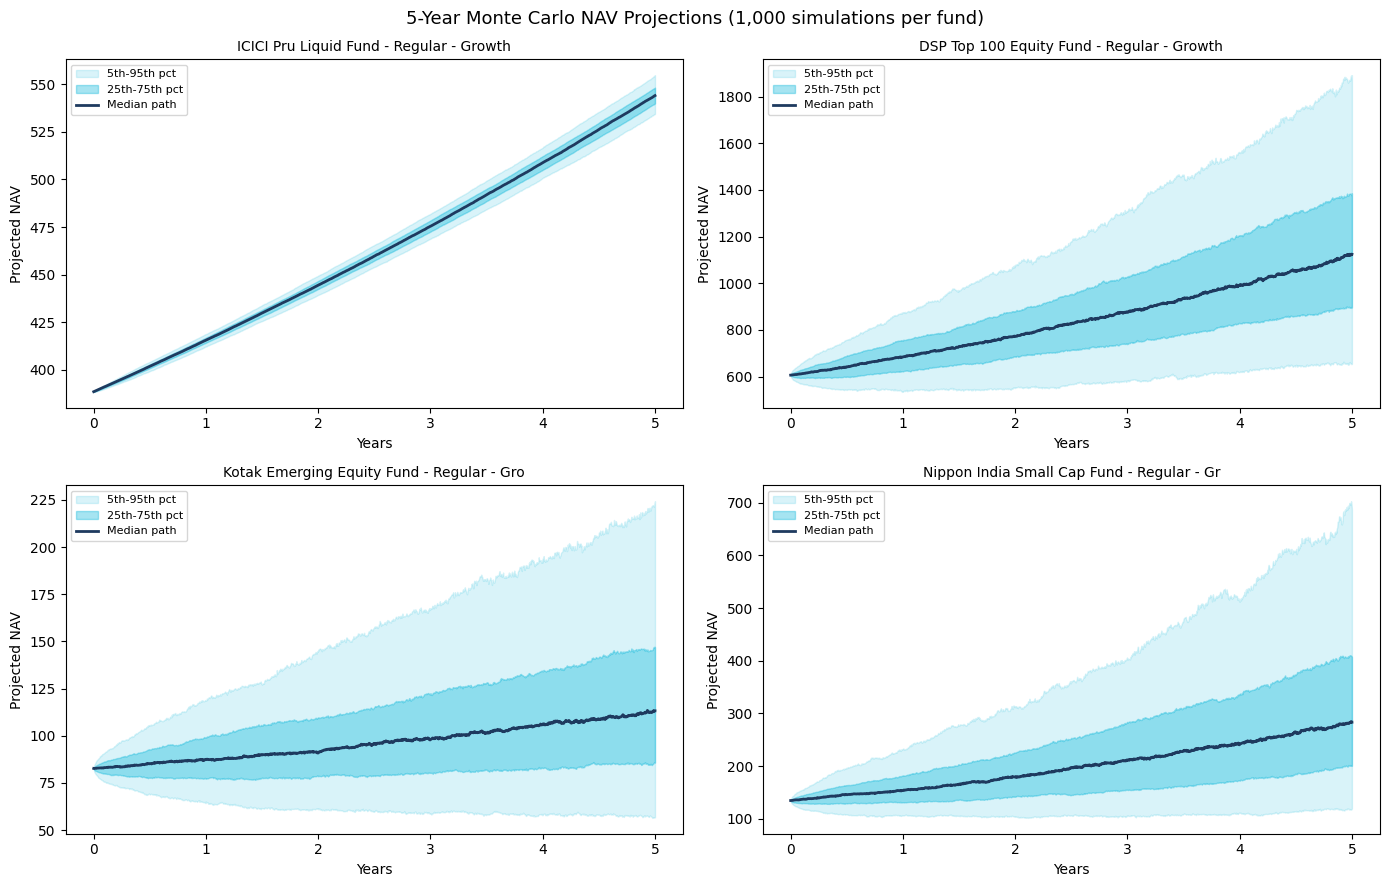

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, code_ in zip(axes, selected):
    paths = simulation_results[code_]["paths"]
    days = np.arange(paths.shape[1])
    years = days / 252

    p5 = np.percentile(paths, 5, axis=0)
    p25 = np.percentile(paths, 25, axis=0)
    p50 = np.percentile(paths, 50, axis=0)
    p75 = np.percentile(paths, 75, axis=0)
    p95 = np.percentile(paths, 95, axis=0)

    ax.fill_between(years, p5, p95, color="#00B4D8", alpha=0.15, label="5th-95th pct")
    ax.fill_between(years, p25, p75, color="#00B4D8", alpha=0.35, label="25th-75th pct")
    ax.plot(years, p50, color="#1E3A5F", linewidth=2, label="Median path")

    name = scheme_names.get(code_, str(code_))
    ax.set_title(name[:42], fontsize=10)
    ax.set_xlabel("Years")
    ax.set_ylabel("Projected NAV")
    ax.legend(fontsize=8)

plt.suptitle("5-Year Monte Carlo NAV Projections (1,000 simulations per fund)", fontsize=13)
plt.tight_layout()
plt.savefig("monte_carlo_nav_projection.png", dpi=150)
plt.show()

## Summary table — projected NAV outcomes at 5 years

In [5]:
summary_rows = []
for code_ in selected:
    paths = simulation_results[code_]["paths"]
    final = paths[:, -1]
    start = simulation_results[code_]["last_nav"]
    summary_rows.append({
        "scheme_name": scheme_names.get(code_, code_),
        "start_nav": round(start, 2),
        "median_5yr_nav": round(np.percentile(final, 50), 2),
        "p5_5yr_nav": round(np.percentile(final, 5), 2),
        "p95_5yr_nav": round(np.percentile(final, 95), 2),
        "median_cagr_pct": round(((np.percentile(final, 50) / start) ** (1/5) - 1) * 100, 2),
    })

monte_carlo_summary = pd.DataFrame(summary_rows)
monte_carlo_summary.to_csv("monte_carlo_summary.csv", index=False)
monte_carlo_summary

,scheme_name,start_nav,median_5yr_nav,p5_5yr_nav,p95_5yr_nav,median_cagr_pct
0,ICICI Pru Liquid Fund - Regular - Growth,388.59,544.04,534.43,554.76,6.96
1,DSP Top 100 Equity Fund - Regular - Growth,606.23,1124.32,655.36,1891.89,13.15
2,Kotak Emerging Equity Fund - Regular - Growth,82.65,113.20,56.71,224.29,6.49
3,Nippon India Small Cap Fund - Regular - Growth,134.67,283.30,119.68,687.25,16.04


**Note:** this simulation assumes returns are i.i.d. Normal (GBM), which is a simplification — real fund returns can show fat tails and volatility clustering. Treat the bands as a rough uncertainty estimate, not a guarantee.